<a href="https://colab.research.google.com/github/Mariamonsalve1305/drivers-de-comportamiento-en-NovaRetail-/blob/main/Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

In [ ]:
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


### Cargar Dataset

#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


### Exploración y Limpieza

In [ ]:

# mostrar las primeras 5 filas
df.head(5)


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


*Se evidencia una Primary Key: id_cliente / tipo_dispositivo con posibles catacteres especiales , es necesario revisar si existen o no nulos o falsos nulos.*

## Sección 2 - Preparar datos y documentar supuestos

In [ ]:
# cantidad de nulos para df
print(df.isna().sum())
print(df.isna().mean())

id_cliente                   0
edad                         0
nivel_ingreso                0
visitas_mes                  0
compras_mes                  0
gasto_publicidad_dirigida    0
satisfaccion                 0
miembro_premium              0
abandono                     0
tipo_dispositivo             0
region                       0
ingreso_anual                0
dtype: int64
id_cliente                   0.0
edad                         0.0
nivel_ingreso                0.0
visitas_mes                  0.0
compras_mes                  0.0
gasto_publicidad_dirigida    0.0
satisfaccion                 0.0
miembro_premium              0.0
abandono                     0.0
tipo_dispositivo             0.0
region                       0.0
ingreso_anual                0.0
dtype: float64


💡 2.2. Detección de valores inválidos y sentinels

🎯 Objetivo:
Identificar sentinels: valores que no deberían estar en el dataset.

In [ ]:
# explorar columnas categóricas de df
columnas_category = df[['tipo_dispositivo', 'region']]

# Aplicar el describe
columnas_category.value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64

*Se puede observar que para las categorias de tipo_dispositivo solo existen (3) móvil, escritorio y tablet asi mismo para las regiones es decir no presenta diferencias en la escritura de una misma categoria lo cual puede concluir que se encuentran estandarizados*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [ ]:
df['id_cliente'].duplicated().sum()

0

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

Llave primaria: id_cliente la cual no cuenta con valores repetidos y en los 15.000 registros se encuentran como valores unicos asociados al cliente y su identificacion.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
la columna `edad` y `ingreso_anual` deben corregir el tipo de dato a int64

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato de edad float a integer
df['edad'] = df['edad'].astype('int64')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


In [ ]:
# Corregir el tipo de dato de ingreso_anual primero multiplicando por 1000 y convertir a integer.
df['ingreso_anual'] = (df['ingreso_anual'] * 1000).astype('int64')


In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 1.4+ MB


In [ ]:
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23220
1,CL-100001,36,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93470
2,CL-100002,46,30642.95,9,0,0.00,2.9,0,0,móvil,este,0
3,CL-100003,56,39468.61,8,0,6.81,3.1,0,0,móvil,este,0
4,CL-100004,35,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33760


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida','ingreso_anual', 'satisfaccion']]

columnas_numericas.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual,satisfaccion
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,36594.170733,3.603693
std,11.492378,9833.166305,3.158189,1.105284,10.880724,34484.885424,0.685300
min,18.000000,8000.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,0.000000,3.100000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,30705.000000,3.600000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,58220.000000,4.100000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,244690.000000,5.000000


✍️ **Comentarios acerca las estadisticas basicas de variables numericas**:

Diagnóstico inicial de variables numéricas

- `edad` - los valores minimos de edad son 18 anos y el maximo es 75, tambien la desviacion estandar nota que aproximadamente el 68% son adultos de entre 26 y 50 años al estar con variacion del 11.49 sobre la media. tambien menos del 25% tienen 30 anos.
- `nivel_ingreso` - los valores se mantienen en un rango de [8000 - 74790]
- `visitas_mes` -  el nivel maximo de visitas al mes es de 25 y minimo 1 en promedio se visita 10 veces
- `compras_mes` - las compras al mes en promedio es una, y las maximas son 8, almenos el 75% ha realizado 2 compras, tambien se han reflejado 0 compras en un mes como valor minimo.
- `gasto_publicidad_dirigida` - El mayor gasto de publicidad es de 75.5100 como tambien refleja cero inversion en publcidad como valor minimo.
- `ingreso_anual` - El mayor ingreso representa un valor de 244690 y un valor minimo de 0 que concuerda con los valores de 0 tambnien de gasto publicitario compras del mes.
- `satisfaccion` - indica que han tenido clientes con satisfaccion 1 y 5 y que el promedio esta en 3.6

#### Explorar variables binarias

In [ ]:
df['abandono'].value_counts()

0    12739
1     2261
Name: abandono, dtype: int64

In [ ]:
df['miembro_premium'].value_counts()

0    12911
1     2089
Name: miembro_premium, dtype: int64

✍️ **Comentarios acerca las estadisticas basicas de variables binarias**:

Diagnóstico inicial de variables binarias

- `miembro_premium` — presentan valores codificados 0 y 1, la mayoria de los datos se encuentran asociados a 0.
- `abandono` — Presentan valores codificados entre 0 y 1, en donde la matoria de los datos tambien se encuentran asociados a 0.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[['miembro_premium', 'abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
df['region'].value_counts()

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

In [ ]:
# Contar cuántos clientes hay por región
df['tipo_dispositivo'].value_counts()

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

✍️ **Comentarios acerca las estadisticas basicas de variables Categoricas**:
Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — corresponde a tres tipos de categorias: (movil, escritorio, tablet), en donde la categoria que mas se repite es movil con la mayor cantidad de datos asociados.
- `region` - Se caracteriza por tener 4 regiones (norte, oeste, sur y este) en donde la categoria que se asocia a la mayoria de datos es norte.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

*Primero se grafica la matriz de correlacion con solo las variables numericas*

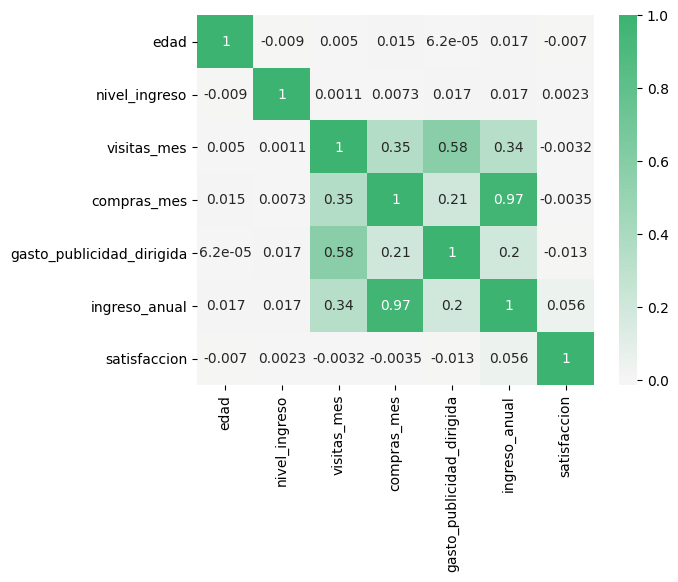

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
# matriz de correlación
df_corr= df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida','ingreso_anual','satisfaccion']].corr()
# crear paleta de colores
custom_cmap = LinearSegmentedColormap.from_list("TT_colors", ["peachpuff", "whitesmoke", "mediumseagreen"])
# crear heatmap
sns.heatmap(df_corr, annot=True, cmap=custom_cmap, center=0)
plt.show()

Observaciones generales (Heatmap)  
- La correlación más fuerte del mapa es la que existe entre compras_mes e ingreso_anual, con un valor de 0.97. Le sigue la relación entre visitas_mes y gasto_publicidad_dirigida (0.58), que es moderada-alta, y luego dos correlaciones moderadas: visitas_mes con compras_mes (0.35) y visitas_mes con ingreso_anual (0.34). La relación entre compras_mes y gasto_publicidad_dirigida es más débil, de 0.21, similar a la de gasto_publicidad_dirigida con ingreso_anual (0.2). No hay ninguna correlación negativa relevante; la única negativa visible es la de edad con nivel_ingreso, y es prácticamente nula (-0.009).


Observaciones respecto a `ingreso_anual`  
- Presenta una relación lineal positiva entre el número de compras al mes y el ingreso anual


### Scatterplot general

*Se diagrama el Scatterplot teniendo en cuenta todas las variables independientemente si son numericas, binarias o categoricas, lo anterior para definir mas adelante las relaciones de las mismas en metodologias de calculo de correlacion como punto biserial o V de cramer*

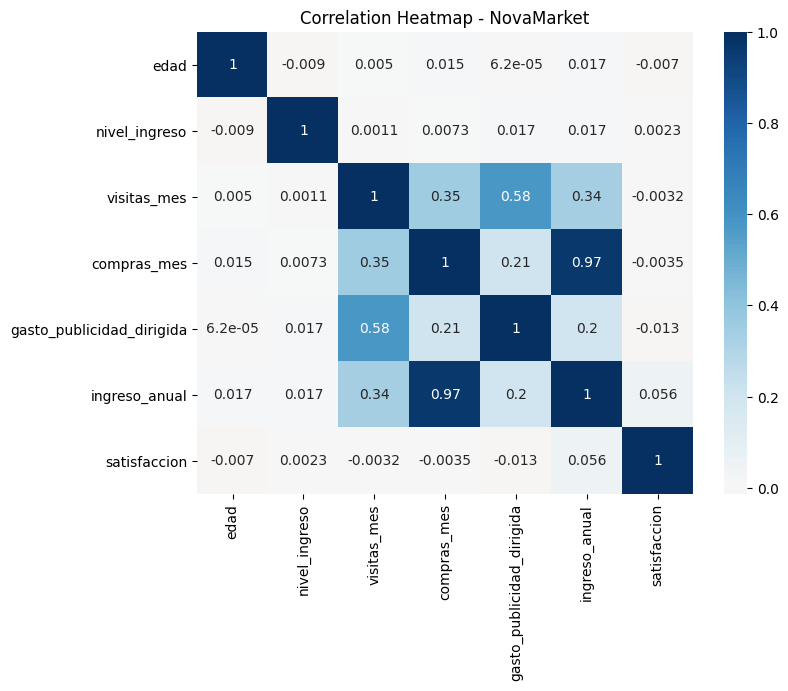

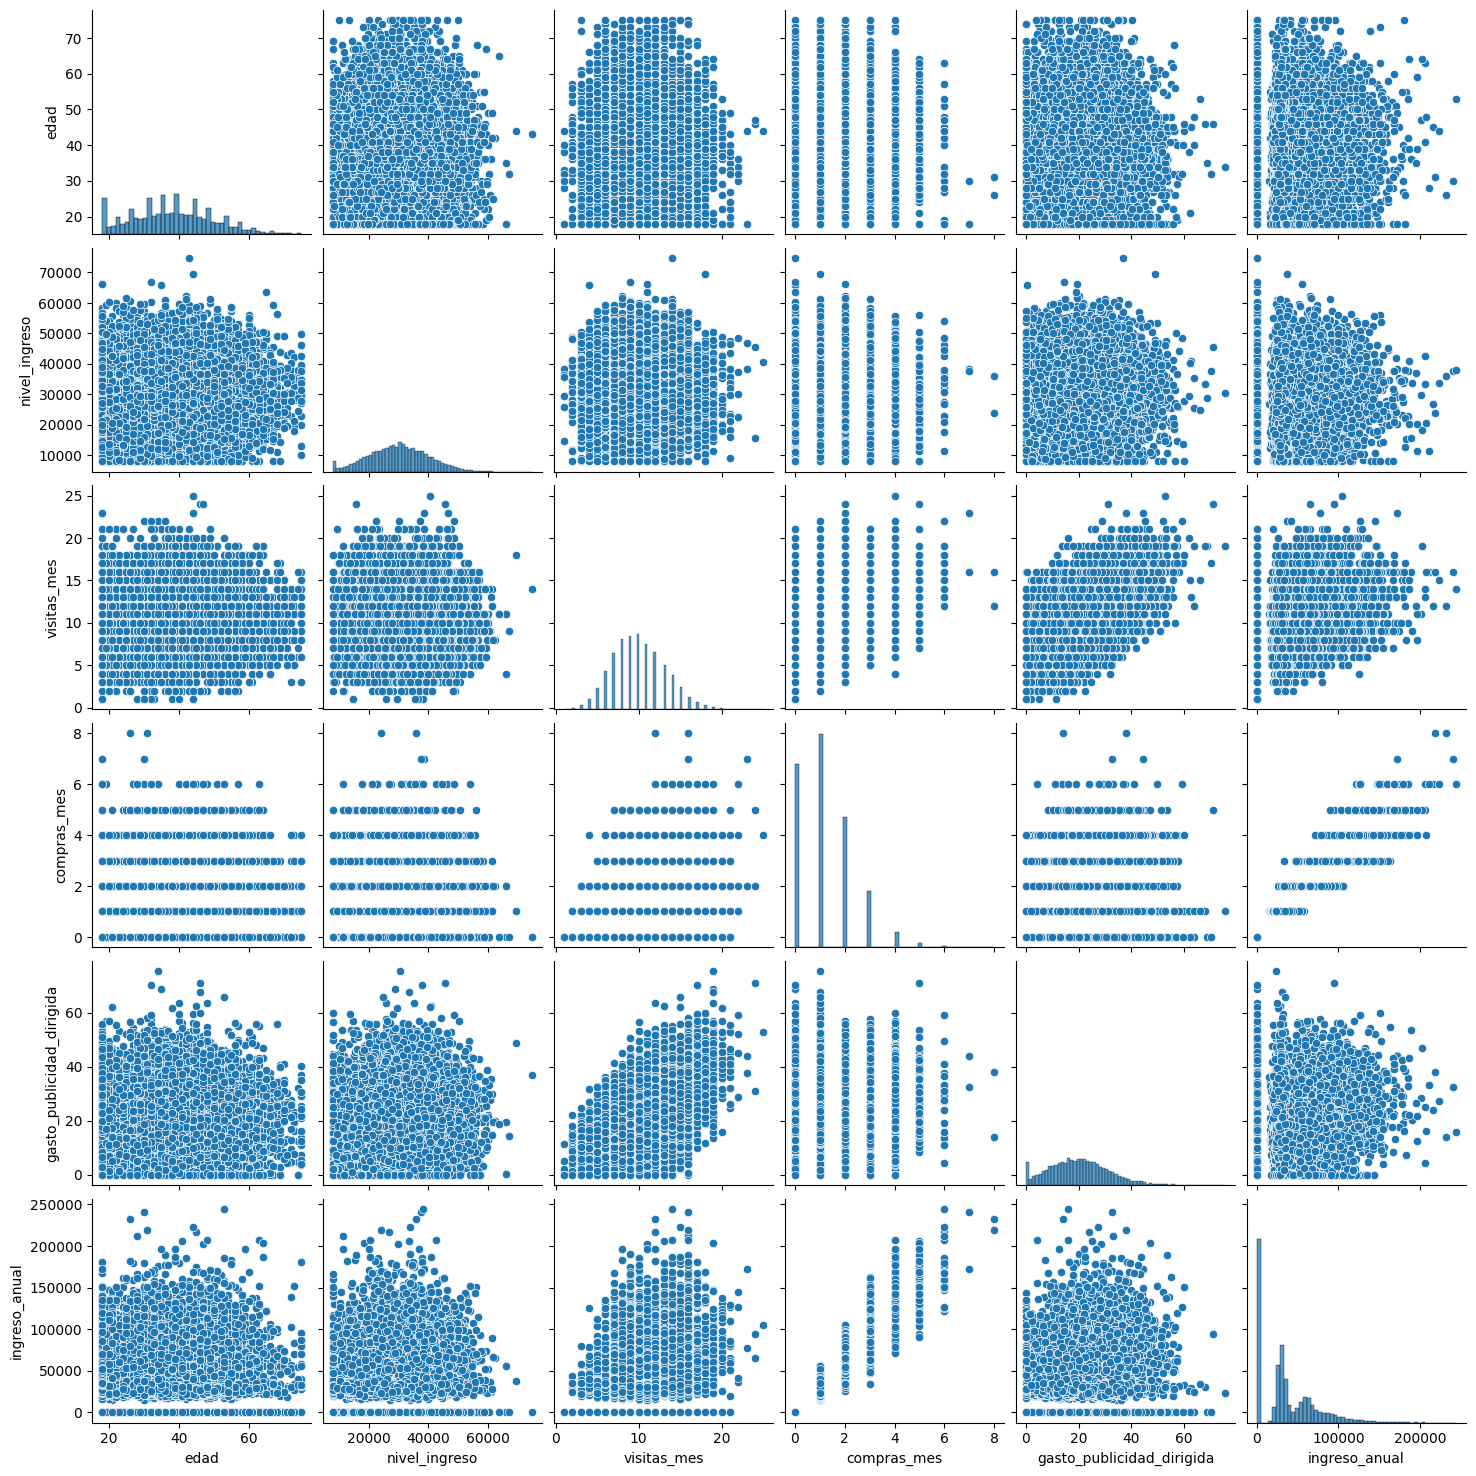

In [ ]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap - NovaMarket")
sns.pairplot(df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida','ingreso_anual']])
plt.show()


El scatterplot matrix confirma visualmente los patrones que ya se veían en el heatmap de correlaciones, y añade información sobre la forma de las relaciones que un coeficiente numérico no puede mostrar.
La relación más clara y fuerte sigue siendo la de compras_mes con ingreso_anual: en el panel correspondiente se observa que a medida que aumenta compras_mes, los valores de ingreso_anual se desplazan claramente hacia arriba, formando bandas verticales ascendentes (la verticalidad se debe a que compras_mes es una variable discreta con pocos valores posibles, de 0 a 8). Esto es consistente con el 0.97 de correlación.

  - mediante la diagramacion de multiples distribuciones me permite identificar sobre la tendencia si es positiva o negativa de acuerdo a su inclinacion asi mismo comprender un poco mejor la dinamica de los datos.

### Scatterplot para pares clave

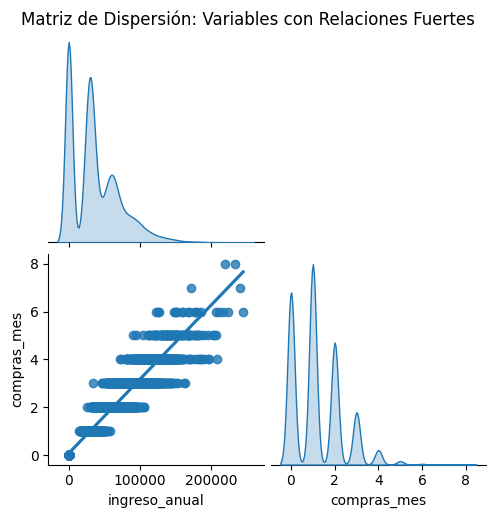

In [ ]:

# Visualizar pares de variables con relaciones moderadas o fuertes
variables_interes_1 = [
    "ingreso_anual",
    "compras_mes",
]

# Creamos el pairplot
sns.pairplot(df[variables_interes_1], kind="reg", diag_kind="kde", corner=True)
plt.suptitle(
    "Matriz de Dispersión: Variables con Relaciones Fuertes", y=1.02
)
plt.show()


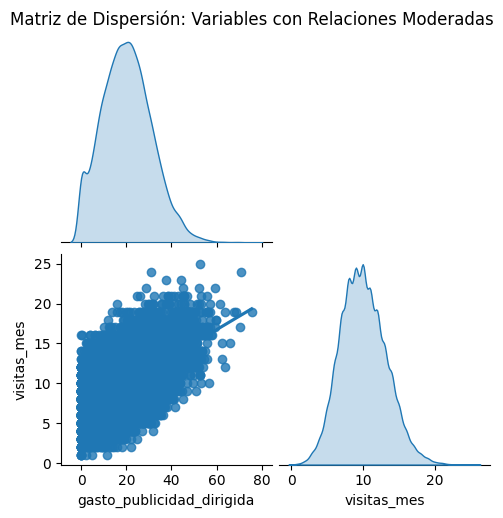

In [ ]:


variables_interes_2 = [
    "gasto_publicidad_dirigida",
    "visitas_mes",
]

# Creamos el pairplot
sns.pairplot(df[variables_interes_2], kind="reg", diag_kind="kde", corner=True)
plt.suptitle(
    "Matriz de Dispersión: Variables con Relaciones Moderadas", y=1.02
)
plt.show()



✍️ **Comentario**:
Observaciones iniciales (Scatterplot)

**var1 vs var2**
- Dirección: Positiva. Se observa claramente que a medida que aumentan los valores en el eje horizontal (ingreso_anual), los valores del eje vertical (compras_mes) también tienden a incrementarse, siguiendo la línea de regresión de forma ascendente
- Dispersion: Baja. Los puntos se agrupan de forma bastante estrecha y compacta alrededor de la línea de tendencia central, lo que denota una relación altamente predecible (lineal y directa)
- Presencia de outliers: Muy baja/Nula. No se aprecian puntos excesivamente aislados o desconectados de la estructura principal.

**var1 vs var3**
- Dirección:Positiva. La nube de puntos y la línea de regresión muestran una inclinación ascendente.
- Dispersion:Media-Alta, aquí los puntos forman una "nube" mucho más ancha y dispersa. Existe bastante variabilidad.
- Presencia de outliers: Moderada. Se observan algunos valores atípicos en la zona superior derecha del gráfico

## Sección 4 - Coeficientes de correlación y evidencia numérica


### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes ingreso_anual & compras_mes

corr_colinealidad = df['ingreso_anual'].corr(df['compras_mes'], method='pearson')

# Mostrar resultado
print("Correlación Pearson:", corr_colinealidad)



Correlación Pearson: 0.9671485556581124


In [ ]:
# Calcular correlación entre variables relevantes moderadas gasto_publicidad_dirigida & visitas_mes
corr_colinealidad_2 = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')

# Mostrar resultado
print("Correlación Pearson:", corr_colinealidad_2)

Correlación Pearson: 0.5592673242622609


✍️ **Observaciones de correlación**:

**var1 vs var2**
- Correlación entre las variables ingreso_anual & compras_mes con el metodo pearson es valido mencionar que esta se da porque ambas son numericas ademas presentan distribucion normal  y relacion lineal. el valor calculado para esta correlacion es de 0.96 ⬆️ ≥ +0.85 → relación muy fuerte,⚠️ posible colinealidad

**var2 vs var3**
- Correlación entre las gasto_publicidad_dirigida & visitas_mes con el metodo spearman argumentando que esta se da porque ambas son numericas pero que ademas presentan una relacion monotoma con posibles outliers, al ser una distribucion mas alta, el valor calculado para esta correlacion es de 0.55 ⬆️ +0.5 a +0.85 → relación moderada positiva
-

### Punto-biserial

In [ ]:

# Calcular correlación entre variables relevantes una numerica y una binaria
pointbiserialr(df["miembro_premium"], df["ingreso_anual"])


SignificanceResult(statistic=0.09309947123065059, pvalue=3.0941688116363186e-30)

El coeficiente de correlación es 0.93
Es un valor positivo, grande, lo que indica que la diferencia entre los dos grupos es fuerte.

In [ ]:
# Calcular correlación entre variables relevantes una numerica y una binaria
pointbiserialr(df["abandono"], df["ingreso_anual"])

SignificanceResult(statistic=-0.0028239507122600873, pvalue=0.729467635684771)

✍️
 **Comentario**:

**var1 vs var2**

> 0.50 → relación fuerte Y 0.93 está muy cerca de 1, lo que indica una relación extremadamente fuerte

Significa que los clientes miembro premium tienen ingresos anuales significativamente más altos que los no premium.

**var2 vs var3**
- 0.00 → no hay relación entre la variable abandono con el ingreso anual


### V de Cramér

In [ ]:

# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    # paso 1: tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # paso 2: calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # paso 3: calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v


In [ ]:

# Aplicar V de Cramér en variables relevantes
cramer_v(df,"region","tipo_dispositivo")


0.012378338407739397

✍️ **Comentario**:
Observaciones V de Cramér entre las variables region y tipo de dispostivio ambas categoricas arroja como resultado: 0.00 – 0.10 lo cual es muy débil, indica poca relación



## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 —

**Evidencia visual:**   Matriz de correlación (Heatmap) generada en el Paso 3

**Evidencia numérica:** Coeficiente de correlación de Pearson con un valor de $r = 0.98$.

**Interpretación**  Existe una asociación lineal positiva extremadamente fuerte (casi perfecta) entre los ingresos_anuales de los clientes y la cantidad de compras_mes que realizan. Esto demuestra numéricamente que el poder adquisitivo es el factor más determinante en la frecuencia de transacciones dentro de NovaRetail; a mayor nivel de ingresos, el volumen de compras mensuales se incrementa de forma casi matemática y constante.

**No podemos afirmar**  No podemos afirmar No se puede asumir que un aumento en los ingresos del cliente se deba a una acción directa de NovaRetail (ya que es una variable demográfica externa), ni tampoco que los clientes de ingresos bajos nunca vayan a comprar, sino que estadísticamente su frecuencia de compra actual es significativamente menor.

**Implicación de negocio**  Este es el hallazgo más potente para la estrategia comercial. El negocio debe priorizar esfuerzos de segmentación (clústeres) para identificar y fidelizar al segmento de clientes con ingresos más altos. Estrategias como programas de suscripción premium, ofertas exclusivas de productos de mayor margen o atención personalizada para este grupo garantizarán la retención del flujo de ingresos más crítico de la plataforma.


### Hallazgo 2 —

**Evidencia visual:**   Matriz de correlación (Heatmap) generada en el Paso 3

**Evidencia numérica:** Coeficiente de correlación de Pearson con un valor de $r = 0.58$.

**Interpretación**  Existe una asociación lineal positiva de magnitud moderada entre el presupuesto asignado a gasto_publicidad_dirigida y el volumen de visitas_mes. Esto indica que las campañas publicitarias específicas están siendo efectivas para atraer tráfico al sitio web de NovaRetail de manera consistente, aunque no de forma tan rígida o directa como el factor del ingreso.

**No podemos afirmar**  No podemos afirmar No podemos asegurar una relación de causalidad aislada (es decir, que la publicidad sea la única razón por la que entran los usuarios), ni tampoco que duplicar el presupuesto vaya a duplicar automáticamente las visitas, ya que al ser una correlación moderada ($0.58$), existen otras variables (como la estacionalidad, ofertas competitivas o el tráfico orgánico) que también intervienen en el comportamiento del tráfico.

**Implicación de negocio** Implicación de negocio La publicidad dirigida funciona y es un motor relevante, pero no debe ser la única herramienta de atracción. Se sugiere mantener la inversión pero optimizando la eficiencia del gasto mediante pruebas A/B y segmentación avanzada, asegurando que los anuncios impacten idealmente al perfil de cliente de alta frecuencia identificado en el Hallazgo 1 para maximizar el retorno de inversión.



## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

Correlación no implica causalidad: Los coeficientes obtenidos ($r = 0.98$ y $r = 0.58$) demuestran una fuerte asociación estadística, pero no prueban matemáticamente que una variable sea la causa directa de la otra.

Presencia de variables no medidas: El análisis actual no contempla factores externos críticos como la estacionalidad, las campañas de descuento de la competencia, la experiencia de usuario (UX) del sitio o la inversión en otros canales de marketing (redes sociales, SEO, etc.).

Sesgo de perfil demográfico: La relación casi perfecta entre ingresos y compras mensuales podría estar influenciada por un sesgo en la muestra de clientes actuales, sin reflejar el comportamiento de usuarios potenciales fuera de ese rango de ingresos.

### **Próximos pasos**

Implementar segmentación avanzada (Clustering): Dividir a la base de clientes en clústeres específicos según su nivel de ingresos y frecuencia de compra para diseñar estrategias de retención adaptadas a cada perfil.

Diseñar experimentos controlados (Pruebas A/B): Realizar pruebas variando el presupuesto de la publicidad dirigida en regiones o periodos específicos para medir el impacto neto real en las visitas y aislar el efecto de otras variables.

Integrar nuevas variables al modelo: Recolectar e incluir en el próximo análisis datos cualitativos y de comportamiento, tales como el tiempo de permanencia en el sitio, la tasa de abandono del carrito y el costo de adquisición por cliente (CAC).